In [1]:
# importing libraries
import tensorflow 
import keras  
import os
import glob 
from skimage import io 
import random 
import numpy as np
import matplotlib.pyplot as plt  
%matplotlib inline

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

In [2]:
# Importing and Loading the data into a data frame

dataset_path = '/kaggle/input/magnetogram-2/magnetogram_images'
class_names = ['alpha', 'beta', 'betax']

# apply glob module to retrieve files/pathnames  

sunspot_path = os.path.join(dataset_path, class_names[1], '*')
sunspot_path = glob.glob(sunspot_path)
sunspot_path

['/kaggle/input/magnetogram-2/magnetogram_images/beta/2013-10-20_524.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2015-11-25_2760.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2013-11-19_630.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2017-03-02_3390.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2015-03-30_2187.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2015-01-19_2045.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2014-06-10_1359.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2013-07-30_271.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2013-06-15_157.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2015-09-27_2610.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2017-06-19_3459.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2015-11-25_2761.jpg',
 '/kaggle/input/magnetogram-2/magnetogram_images/beta/2015-09-07_2562.jpg',
 '/kaggle/input/

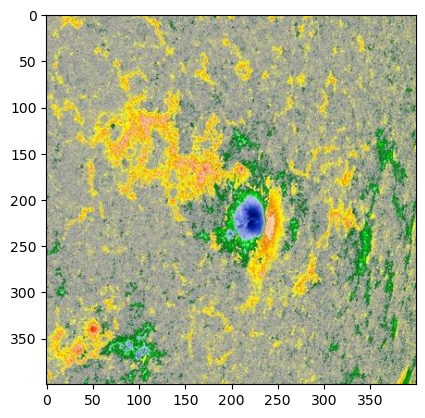

In [3]:
# accessing an image file from the dataset classes
image = io.imread(sunspot_path[4])  

# plotting the original image
i, (im1) = plt.subplots(1)
i.set_figwidth(15)
im1.imshow(image)

Text(0.5, 0.98, 'Original & RGB image channels')

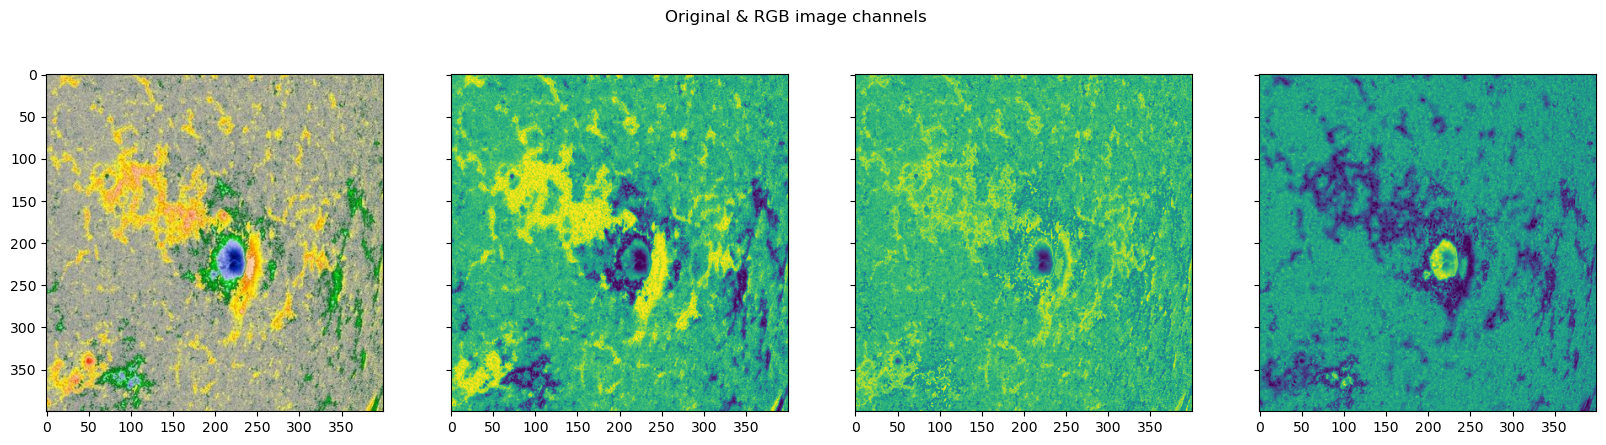

In [4]:
# plotting the original image and the RGB channels  

i, (im1, im2, im3, im4) = plt.subplots(1, 4, sharey=True)
i.set_figwidth(20) 

im1.imshow(image)  #Original image
im2.imshow(image[:, : , 0]) #Red
im3.imshow(image[:, : , 1]) #Green
im4.imshow(image[:, : , 2]) #Blue
i.suptitle('Original & RGB image channels')

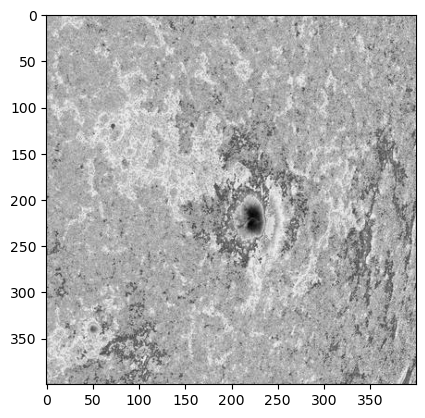

In [5]:
from skimage import io
import skimage
gray_image = skimage.color.rgb2gray(image)
plt.imshow(gray_image, cmap = 'gray')

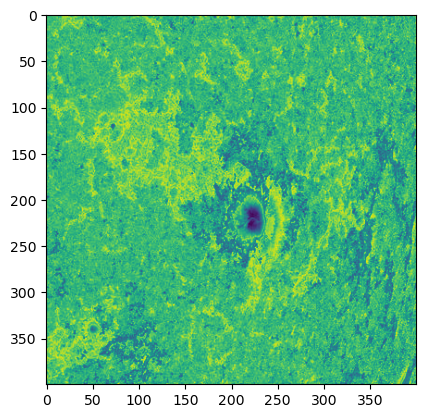

In [6]:
norm_image = (gray_image - np.min(gray_image)) / (np.max(gray_image) - np.min(gray_image))
plt.imshow(norm_image)

In [7]:
from numpy import expand_dims
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from keras.preprocessing.image import ImageDataGenerator

# convert to numpy array
data = img_to_array(image)

# expand dimension to one sample
samples = expand_dims(image, 0)

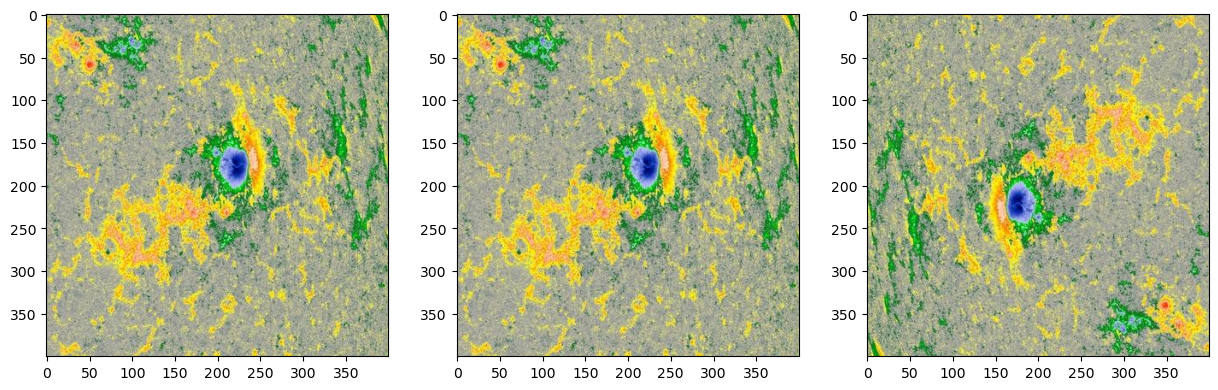

In [8]:
# ImageDataGenerator for flipping
datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True)

# create an iterator
it = datagen.flow(samples, batch_size=1)
fig, im = plt.subplots(nrows=1, ncols=3, figsize=(15,15))

# generate batch of images
for i in range(3):

    # convert to unsigned integers
    image = next(it)[0].astype('uint8')
 
    # plot image
    im[i].imshow(image) 

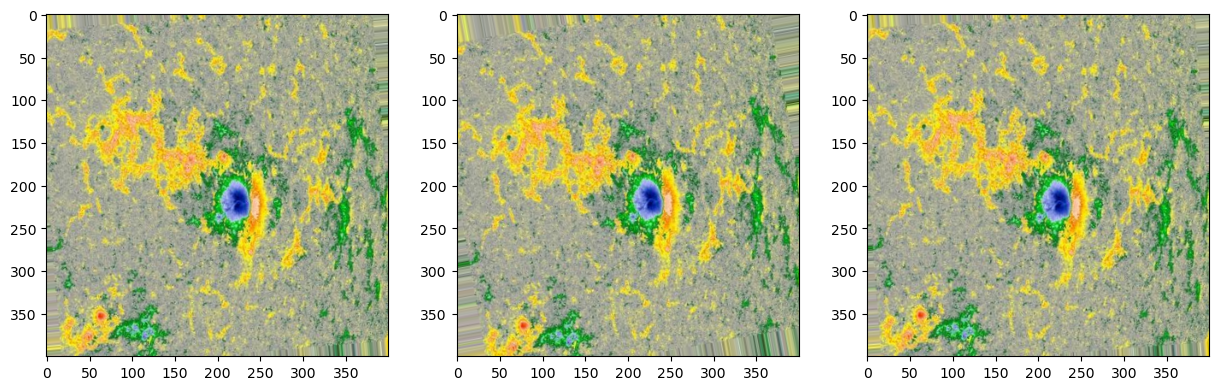

In [9]:
datagen = ImageDataGenerator(rotation_range=20, fill_mode='nearest')

# create an iterator
it = datagen.flow(samples, batch_size=1)
fig, im = plt.subplots(nrows=1, ncols=3, figsize=(15,15))

# generate batch of images
for i in range(3):

    # convert to unsigned integers
    image = next(it)[0].astype('uint8')
 
    # plot image
    im[i].imshow(image) 

/opt/conda/lib/python3.10/site-packages/keras/preprocessing/image.py:1861: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/keras/preprocessing/image.py:1871: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


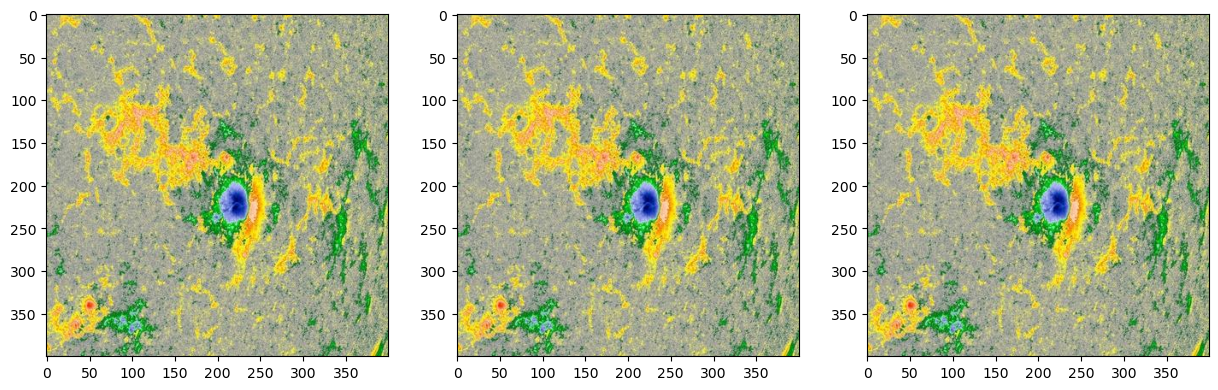

In [10]:
# creating the image data generator to standardize images
datagen = ImageDataGenerator(featurewise_center =True,
      featurewise_std_normalization = True)

# create an iterator
it = datagen.flow(samples, batch_size=1)
fig, im = plt.subplots(nrows=1, ncols=3, figsize=(15,15))

# generate batch of images
for i in range(3):

    # convert to unsigned integers
    image = next(it)[0].astype('uint8')
 
    # plot image
    im[i].imshow(image) 

In [11]:
import keras
from keras.models import Sequential,Input,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers.advanced_activations import LeakyReLU
import tensorflow as tf
from tensorflow import keras
import keras.layers as layers
model = keras.Sequential()
model.add(layers.Conv2D(filters=96, kernel_size=(11, 11), 
                        strides=(4, 4), activation="relu", 
                        input_shape=(227, 227, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPool2D(pool_size=(3, 3), strides= (2, 2)))
model.add(layers.Conv2D(filters=256, kernel_size=(5, 5), 
                        strides=(1, 1), activation="relu", 
                        padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPool2D(pool_size=(3, 3), strides=(2, 2)))
model.add(layers.Conv2D(filters=384, kernel_size=(3, 3), 
                        strides=(1, 1), activation="relu", 
                        padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(filters=384, kernel_size=(3, 3), 
                        strides=(1, 1), activation="relu", 
                        padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(filters=256, kernel_size=(3, 3), 
                        strides=(1, 1), activation="relu", 
                        padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPool2D(pool_size=(3, 3), strides=(2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(4096, activation="relu"))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation="softmax"))
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer=tf.optimizers.SGD(lr=0.001), 
              metrics=['accuracy'])
model.summary()

ImportError: cannot import name 'Input' from 'keras.models' (/opt/conda/lib/python3.10/site-packages/keras/models/__init__.py)

# Try 2

In [ ]:
train_paths_alpha = []
train_paths_beta = []
train_paths_betax = []

ALPHA_PATH=  "/kaggle/input/magnetogram-2/magnetogram_images/alpha"
BETA_PATH = "/kaggle/input/magnetogram-2/magnetogram_images/beta"
BETAX_PATH = "/kaggle/input/magnetogram-2/magnetogram_images/betax"
train_paths_alpha += os.listdir(ALPHA_PATH)
# train_paths_alpha = [ALPHA_PATH + "/"+i for i in train_paths_alpha]

train_paths_beta += os.listdir("/kaggle/input/magnetogram-2/magnetogram_images/beta")
# train_paths_beta = ["/kaggle/input/magnetogram-2/magnetogram_images/beta/"+i for i in train_paths_beta]

train_paths_betax += os.listdir("/kaggle/input/magnetogram-2/magnetogram_images/betax")
# train_paths_betax = ["/kaggle/input/magnetogram-2/magnetogram_images/betax/"+i for i in train_paths_betax]

# ALPHA_PATH = "/kaggle/input/datasetsunspots/imgs/alpha"
# BETA_PATH = "/kaggle/input/datasetsunspots/imgs/beta"
# BETAX_PATH = "/kaggle/input/datasetsunspots/imgs/betax"

train_paths_alpha += os.listdir(ALPHA_PATH)
train_paths_alpha = [ALPHA_PATH +"/"+ i for i in train_paths_alpha]

train_paths_beta += os.listdir(BETA_PATH)
train_paths_beta = [BETA_PATH +"/" + i for i in train_paths_beta]

train_paths_betax += os.listdir(BETAX_PATH)
train_paths_betax = [BETAX_PATH +"/"+ i for i in train_paths_betax]


In [ ]:
# Assign labels to the image paths
train_labels_alpha = [0] * len(train_paths_alpha)
train_labels_beta = [1] * len(train_paths_beta)
train_labels_betax = [2] * len(train_paths_betax)

In [ ]:
# Combine the image paths and labels
paths = train_paths_alpha + train_paths_beta + train_paths_betax
labels = train_labels_alpha + train_labels_beta + train_labels_betax

In [ ]:
data = list(zip(paths, labels))
random.shuffle(data)
paths, labels = zip(*data)

FRACTION = 0.8
train_paths = paths[0:int(FRACTION*len(paths))]
val_paths = paths[int(FRACTION*len(paths)):]

train_labels = labels[0:int(FRACTION*len(labels))]
val_labels = labels[int(FRACTION*len(labels)):]
# print(len(val_paths), len(train_paths))
print("Number of training samples:", len(train_paths))
print("Number of validation samples:", len(val_paths))

In [ ]:
import cv2
IMG_SIZE = 227
training_data = []

def create_training_data(paths, labels, tab):
    try:
        for i in range(len(paths)): 
            img_array = cv2.imread(paths[i], cv2.IMREAD_GRAYSCALE)
            new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            tab.append([new_array, labels[i]])
    except Exception as e:
        print(e)

In [ ]:
create_training_data(train_paths, train_labels, training_data)
len(training_data)

In [ ]:
val_data = []
create_training_data(val_paths, val_labels, val_data)
len(val_data)

In [ ]:
X = []
Y= []
X_val = []
Y_val = []

for features, labels in training_data:
    X.append(features)
    Y.append(labels)
    
X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
Y = np.array(Y)

# X = X / 255.0

for features, labels in val_data:
    X_val.append(features)
    Y_val.append(labels)
    
X_val = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
Y_val = np.array(Y)

# X_val = X_val /255.0

In [ ]:
import keras
from keras.models import Sequential,Model
from keras.layers import Dense, Dropout,Input, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import LeakyReLU
import tensorflow as tf
from tensorflow import keras
import keras.layers as layers

# Model Architecture 

In [ ]:

model = keras.Sequential()
model.add(layers.Conv2D(filters=96, kernel_size=(11, 11), 
                        strides=(4, 4), activation="relu", 
                        input_shape=(227, 227, 1)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPool2D(pool_size=(3, 3), strides= (2, 2)))
model.add(layers.Conv2D(filters=256, kernel_size=(5, 5), 
                        strides=(1, 1), activation="relu", 
                        padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPool2D(pool_size=(3, 3), strides=(2, 2)))
model.add(layers.Conv2D(filters=384, kernel_size=(3, 3), 
                        strides=(1, 1), activation="relu", 
                        padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(filters=384, kernel_size=(3, 3), 
                        strides=(1, 1), activation="relu", 
                        padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(filters=256, kernel_size=(3, 3), 
                        strides=(1, 1), activation="relu", 
                        padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPool2D(pool_size=(3, 3), strides=(2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(4096, activation="relu"))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(3, activation="softmax"))
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer=tf.optimizers.SGD(lr=0.0001), 
              metrics=['accuracy'])
model.summary()

In [ ]:
history = model.fit(X, Y, 
                    batch_size=32, 
                    epochs=200, 
                    validation_data=(X_val, Y_val))

In [ ]:
# Plotting accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
plt.savefig("/kaggle/working/accuracy.png")

In [ ]:
model.save('modelv3.h5')

In [ ]:
os.chdir(r'/kaggle/working')
from IPython.display import FileLink
FileLink(r'modelv3.h5')

In [ ]:
# Get the loss and validation loss values from the history object
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get the number of epochs
epochs = range(1, len(loss) + 1)

# Plot the loss and validation loss
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
test_paths_alpha = []
test_paths_beta = []
test_paths_betax = []

test_paths_alpha += os.listdir("/kaggle/input/test-dataset/test_data/alpha")
test_paths_alpha = ["/kaggle/input/test-dataset/test_data/alpha/"+i for i in train_paths_alpha]

test_paths_beta += os.listdir("/kaggle/input/test-dataset/test_data/beta")
test_paths_beta = ["/kaggle/input/test-dataset/test_data/beta/"+i for i in train_paths_beta]

test_paths_betax += os.listdir("/kaggle/input/test-dataset/test_data/betax")
test_paths_betax = ["/kaggle/input/test-dataset/test_data/betax/"+i for i in train_paths_betax]


In [ ]:
# Assign labels to the image paths
test_labels_alpha = [0] * len(test_paths_alpha)
test_labels_beta = [1] * len(test_paths_beta)
test_labels_betax = [2] * len(test_paths_betax)

In [ ]:
# Combine the image paths and labels
paths = test_paths_alpha + test_paths_beta + test_paths_betax
labels = test_labels_alpha + test_labels_beta + test_labels_betax

In [ ]:
data = list(zip(paths, labels))
random.shuffle(data)
paths, labels = zip(*data)

In [ ]:
test_data=[]
create_training_data(paths, labels, test_data)

In [ ]:
X_pred =[]
Y_true = []
for features, labels in test_data:
    X_pred.append(features)
    Y_true.append(labels)
    
X_pred = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
Y_true = np.array(Y)
# X_pred = X_pred /255.0

In [ ]:
predictions = model.predict(X_pred)
predicted_labels = np.argmax(predictions, axis=1)

In [ ]:
print(predicted_labels)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_true, predicted_labels)
print(cm)

In [ ]:
# Create a figure and axis
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set font scale for better visualization
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
            xticklabels=["alpha", "beta", "betax"], yticklabels=["alpha", "beta", "betax"])

# Customize the plot
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# Show the plot
plt.show()
plt.savefig("/kaggle/working/cm.png")

In [ ]:
from sklearn.metrics import f1_score
# Calculate the F1 score
f1 = f1_score(Y_true, predicted_labels, average='macro')

# Get the TP, TN, FP, FN values
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Print the F1 score and TP, TN, FP, FN values
print("F1 Score:", f1)
print("True Positives:", TP)
print("True Negatives:", TN)
print("False Positives:", FP)
print("False Negatives:", FN)

In [ ]:
img_array = cv2.imread("/kaggle/input/testtttt/3333_HMIBC.jpg", cv2.IMREAD_GRAYSCALE)
new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
X = np.array(new_array).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
predictions = model.predict(X)
predicted_label = np.argmax(predictions, axis=1)
print("cette tache est de classe : "+ str(predicted_label[0]))